# Data Analyst Assessment — E-Commerce Sales Analysis
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (99,441 orders, 2016–2018, 9 relational tables)

**Business Problem:** Analyzing E-commerce Sales and Customer Purchasing Patterns to Identify Revenue Growth Opportunities.

This notebook covers: data import → cleaning → merging → feature engineering → exploratory & business analysis → insight generation.

## 01 — Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 140)
sns.set_style('whitegrid')

customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

for name, d in [('customers',customers),('orders',orders),('order_items',order_items),
                ('order_payments',order_payments),('order_reviews',order_reviews),
                ('products',products),('sellers',sellers)]:
    print(f"{name}: {d.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 6)
order_payments: (103886, 5)
order_reviews: (100000, 7)
products: (32951, 9)
sellers: (3095, 4)


## 02 — Understand the Data

In [2]:
print(orders.isna().sum())
print()
print(orders['order_status'].value_counts())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Observation:** 96,478 of 99,441 orders (97%) are `delivered`. The remainder are cancelled, unavailable,
still processing/shipped, etc. For core revenue analysis we will filter to `delivered` orders only, since
non-delivered orders don't represent realized revenue and often have missing delivery-date fields.

## 03 — Remove Duplicates

In [3]:
print("Duplicate rows -> orders:", orders.duplicated().sum(), "| order_items:", order_items.duplicated().sum(),
      "| customers:", customers.duplicated().sum(), "| products:", products.duplicated().sum())

orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()
customers = customers.drop_duplicates()
products = products.drop_duplicates()

Duplicate rows -> orders: 0 | order_items: 0 | customers: 0 | products: 0


## 04 — Correct Data Types

In [4]:
date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')
orders.dtypes[date_cols]

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## 05 — Handle Missing Values (product category, delivery dates)

In [5]:
products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

missing_delivered = orders['order_delivered_customer_date'].isna().sum()
print(f"Orders with missing delivered_customer_date: {missing_delivered} ({missing_delivered/len(orders)*100:.1f}%)")
print(f"Products with missing category (raw): {products['product_category_name'].isna().sum()}")

Orders with missing delivered_customer_date: 2965 (3.0%)
Products with missing category (raw): 610


## 06 — Join / Merge Related Tables

In [6]:
df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(products[['product_id','product_category_name_english','product_weight_g']], on='product_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')

pay_agg = order_payments.groupby('order_id')['payment_value'].sum().reset_index().rename(columns={'payment_value':'order_total_payment'})
df = df.merge(pay_agg, on='order_id', how='left')

rev_agg = order_reviews.groupby('order_id')['review_score'].mean().reset_index()
df = df.merge(rev_agg, on='order_id', how='left')

print("Merged table shape:", df.shape)
df.head()

Merged table shape: (112650, 24)


,order_id,order_item_id,product_id,seller_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,...,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,product_weight_g,seller_zip_code_prefix,seller_city,seller_state,order_total_payment,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,...,28013,campos dos goytacazes,RJ,cool_stuff,650.0,27277,volta redonda,SP,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,...,15775,santa fe do sul,SP,pet_shop,30000.0,3471,sao paulo,SP,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,...,35661,para de minas,MG,furniture_decor,3050.0,37564,borda da mata,MG,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,...,12952,atibaia,SP,perfumery,200.0,14403,franca,SP,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,...,13226,varzea paulista,SP,garden_tools,3750.0,87900,loanda,PR,218.04,5.0


## 07 — Create Calculated Columns

In [7]:
df['revenue'] = df['price']
df['total_item_value'] = df['price'] + df['freight_value']
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = df['delivery_delay_days'] > 0
df['freight_pct'] = df['freight_value'] / df['price'].replace(0, np.nan) * 100

## 08 — Outlier Analysis

In [8]:
print(df['price'].describe())
q99 = df['price'].quantile(0.99)
print(f"\nItems priced above 99th percentile (R$ {q99:.2f}): {(df['price']>q99).sum()}")
df['price_outlier_flag'] = df['price'] > q99

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

Items priced above 99th percentile (R$ 890.00): 1117


**Decision:** High-price items are kept (they are genuine high-value products, e.g. electronics/furniture,
not data-entry errors) but flagged with `price_outlier_flag` so they can be excluded from per-unit average
calculations if needed.

## 09 — Build Analysis-Ready (Processed) Dataset

In [9]:
valid_statuses = ['delivered']
df_valid = df[df['order_status'].isin(valid_statuses)].copy()
print(f"Rows kept for core analysis (delivered only): {len(df_valid)} of {len(df)}")

df.to_csv('processed_data_full.csv', index=False)
df_valid.to_csv('processed_data_delivered.csv', index=False)
print("Saved processed_data_full.csv and processed_data_delivered.csv")

Rows kept for core analysis (delivered only): 110197 of 112650


Saved processed_data_full.csv and processed_data_delivered.csv


## 10 — Business Analysis & Visualizations

In [10]:
total_revenue = df_valid['revenue'].sum()
n_orders = df_valid['order_id'].nunique()
n_customers = df_valid['customer_unique_id'].nunique()
aov = df_valid.groupby('order_id')['revenue'].sum().mean()

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Orders: {n_orders:,}  |  Customers: {n_customers:,}  |  AOV: R$ {aov:,.2f}")

Total Revenue: R$ 13,221,498.11
Orders: 96,478  |  Customers: 93,358  |  AOV: R$ 137.04


### Revenue by Category

Top 10 categories = 62.4% of total revenue


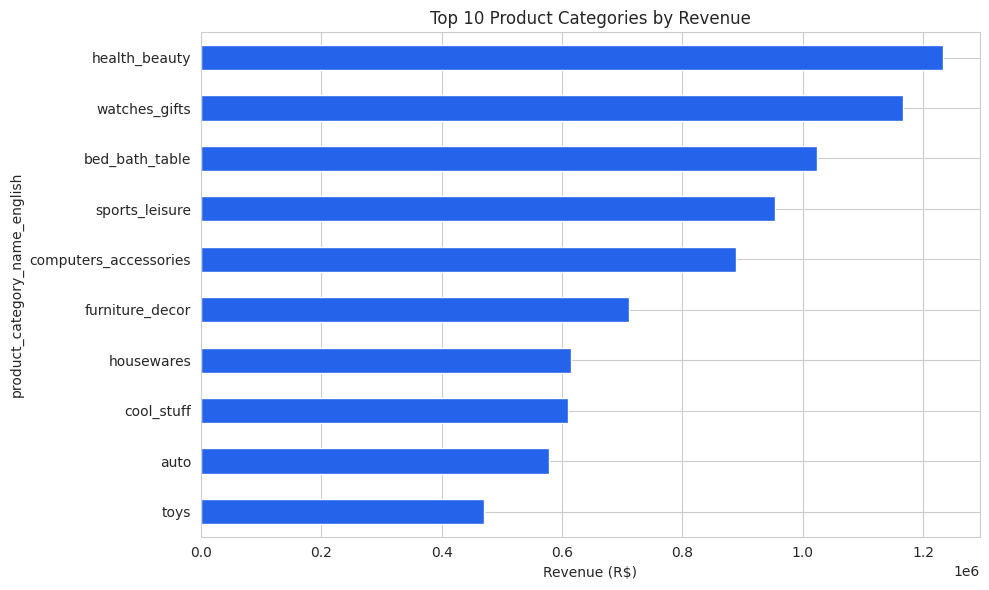

In [11]:
cat_revenue = df_valid.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False)
top10_cat = cat_revenue.head(10)
print(f"Top 10 categories = {top10_cat.sum()/total_revenue*100:.1f}% of total revenue")

plt.figure(figsize=(10,6))
top10_cat.sort_values().plot(kind='barh', color='#2563eb')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.tight_layout()
plt.show()

### Revenue by State

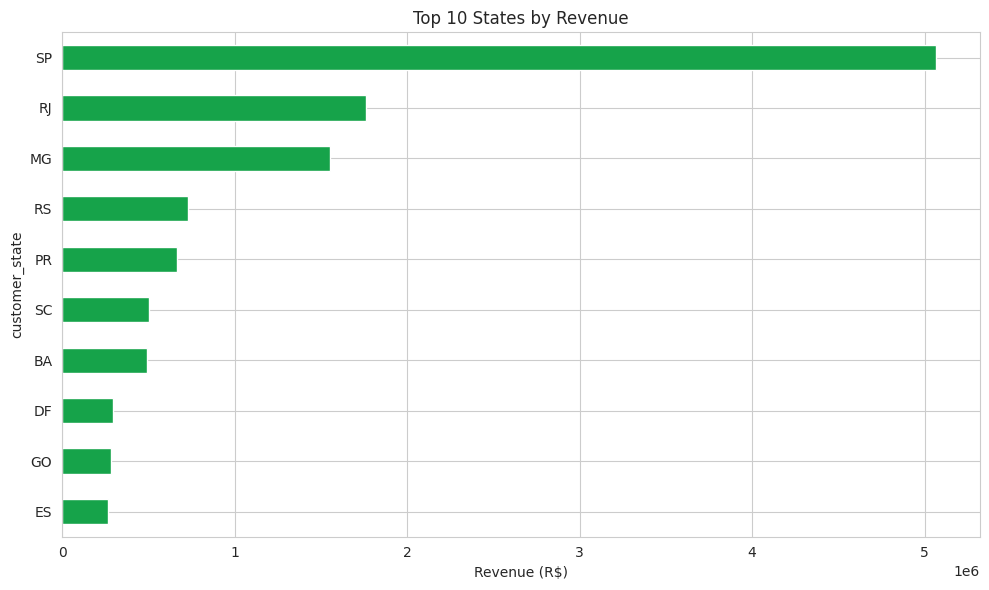

São Paulo (SP) alone = 38.3% of total revenue


In [12]:
state_revenue = df_valid.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
state_revenue.head(10).sort_values().plot(kind='barh', color='#16a34a')
plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue (R$)')
plt.tight_layout()
plt.show()
print(f"São Paulo (SP) alone = {state_revenue['SP']/total_revenue*100:.1f}% of total revenue")

### Monthly Revenue Trend

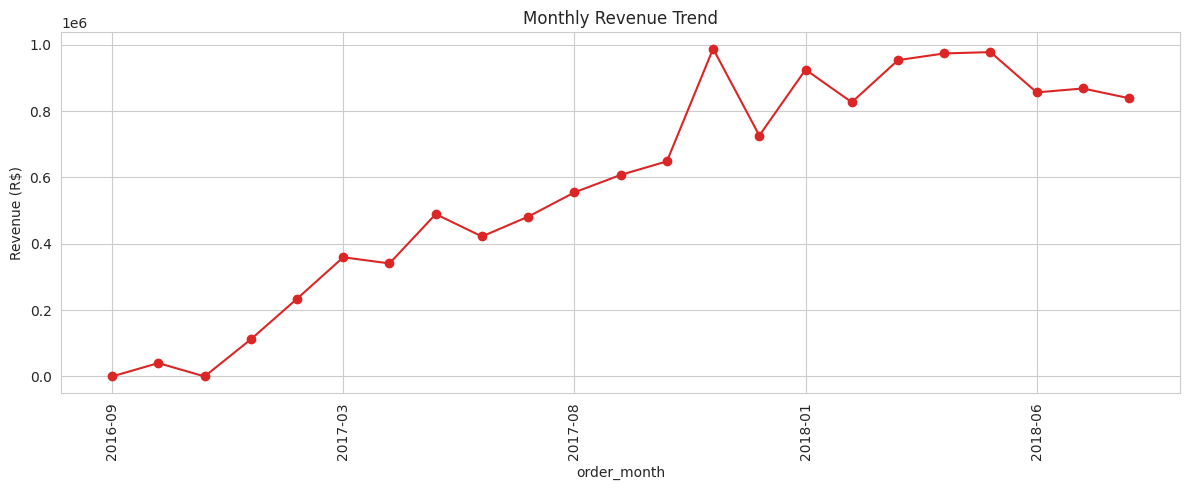

In [13]:
monthly = df_valid.groupby('order_month')['revenue'].sum()
plt.figure(figsize=(12,5))
monthly.plot(kind='line', marker='o', color='#dc2626')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Top Products: Units Sold vs Revenue Generated (checking Hypothesis: best-sellers ≠ top revenue)

In [14]:
prod_stats = df_valid.groupby('product_id').agg(units_sold=('order_item_id','count'), revenue=('revenue','sum')).reset_index()
top_units = prod_stats.sort_values('units_sold', ascending=False).head(10)
top_rev = prod_stats.sort_values('revenue', ascending=False).head(10)
overlap = set(top_units['product_id']) & set(top_rev['product_id'])
print(f"Overlap between top-10-by-units and top-10-by-revenue products: {len(overlap)} / 10")
top_units[['product_id','units_sold','revenue']]

Overlap between top-10-by-units and top-10-by-revenue products: 5 / 10


,product_id,units_sold,revenue
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30
8429,422879e10f46682990de24d770e7f83d,484,26577.22
19290,99a4788cb24856965c36a24e339b6058,477,42049.66
7206,389d119b48cf3043d311335e499d9c6b,390,21336.79
6926,368c6c730842d78016ad823897a372db,388,21056.80
10589,53759a2ecddad2bb87a079a1f1519f73,373,20387.20
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56
10616,53b36df67ebb7c41585e8d54d6772e08,321,37454.63
2734,154e7e31ebfa092203795c972e5804a6,274,6173.26
7881,3dd2a17168ec895c781a9191c1e95ad7,272,40782.80


### Customer Concentration & Repeat Purchase Rate

In [15]:
cust_rev = df_valid.groupby('customer_unique_id')['revenue'].sum().sort_values(ascending=False)
top1000_share = cust_rev.head(1000).sum() / total_revenue * 100
repeat_customers = df_valid.groupby('customer_unique_id')['order_id'].nunique()
pct_repeat = (repeat_customers > 1).mean() * 100
print(f"Top 1,000 customers (~1% of base) generate {top1000_share:.1f}% of revenue")
print(f"Only {pct_repeat:.2f}% of customers placed more than one order")

Top 1,000 customers (~1% of base) generate 12.0% of revenue
Only 3.00% of customers placed more than one order


### Delivery Performance vs Customer Satisfaction

% orders delivered late: 6.6%
Avg review score — on-time: 4.20 | late: 2.24


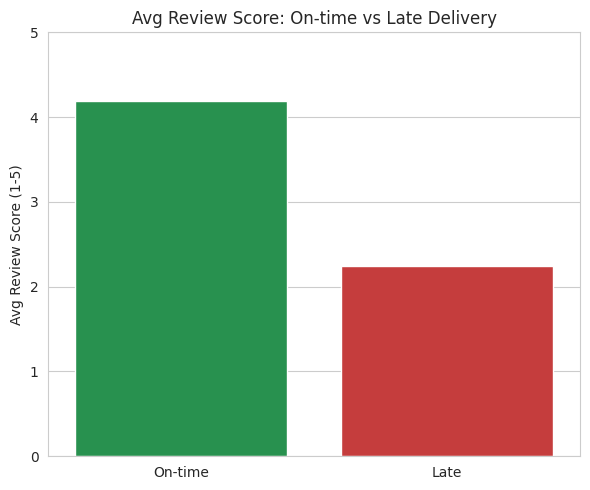

In [16]:
delivery_review = df_valid.dropna(subset=['delivery_delay_days','review_score']).copy()
delivery_review['on_time'] = delivery_review['delivery_delay_days'] <= 0
avg_score_ontime = delivery_review[delivery_review['on_time']]['review_score'].mean()
avg_score_late = delivery_review[~delivery_review['on_time']]['review_score'].mean()
pct_late = (~delivery_review['on_time']).mean() * 100

print(f"% orders delivered late: {pct_late:.1f}%")
print(f"Avg review score — on-time: {avg_score_ontime:.2f} | late: {avg_score_late:.2f}")

plt.figure(figsize=(6,5))
sns.barplot(x=['On-time','Late'], y=[avg_score_ontime, avg_score_late], hue=['On-time','Late'], palette=['#16a34a','#dc2626'], legend=False)
plt.title('Avg Review Score: On-time vs Late Delivery')
plt.ylabel('Avg Review Score (1-5)')
plt.ylim(0,5)
plt.tight_layout()
plt.show()

### Freight Cost Burden by State (logistics insight)

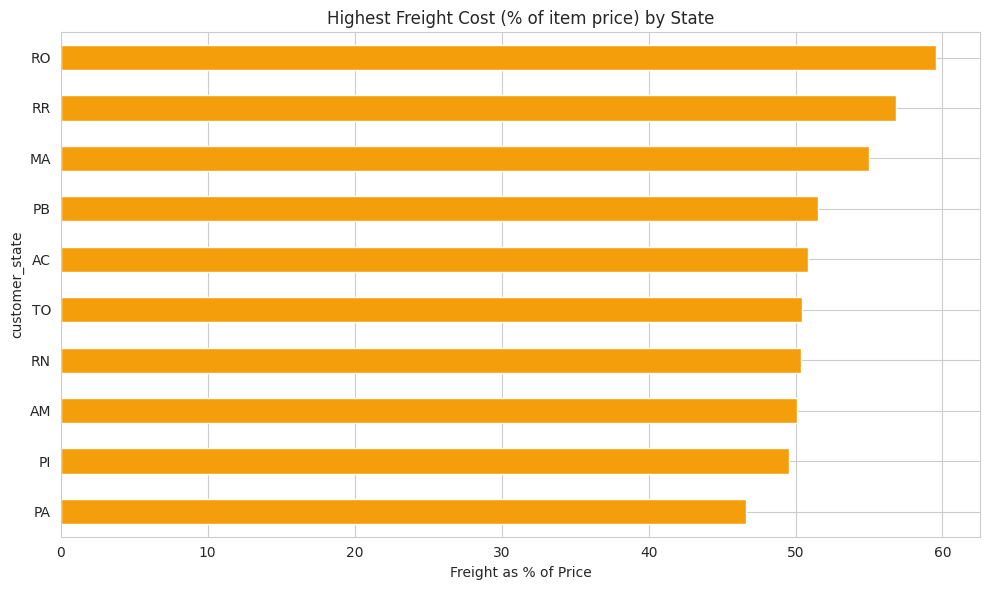

In [17]:
freight_by_state = df_valid.groupby('customer_state')['freight_pct'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
freight_by_state.head(10).sort_values().plot(kind='barh', color='#f59e0b')
plt.title('Highest Freight Cost (% of item price) by State')
plt.xlabel('Freight as % of Price')
plt.tight_layout()
plt.show()

## Summary of Key Business Insights
See **Q4 worksheet** in the accompanying Excel file for the full Insight → Evidence → Business Impact →
Recommendation table. Headline numbers from this notebook:

1. Top 10 of ~74 product categories drive **62.4%** of total revenue.
2. **São Paulo (SP)** alone accounts for **~38%** of all revenue — extreme regional concentration.
3. Only **5 of the top 10** best-selling products (by units) are also in the top 10 by revenue — high-volume
   ≠ high-value.
4. Only **3.0%** of customers are repeat buyers — retention is a major growth lever.
5. Late deliveries (6.6% of orders) correlate with a sharp drop in review score (4.20 → 2.24 avg).
6. Freight cost as a % of item price is 3–4x higher in remote North/Northeast states than in the
   São Paulo hub — a logistics equity/pricing issue.